<a href="https://colab.research.google.com/github/famaadotcom/Data-Analytics-Task/blob/main/Task%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_18258/2103841019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Default', data=df, palette='viridis')


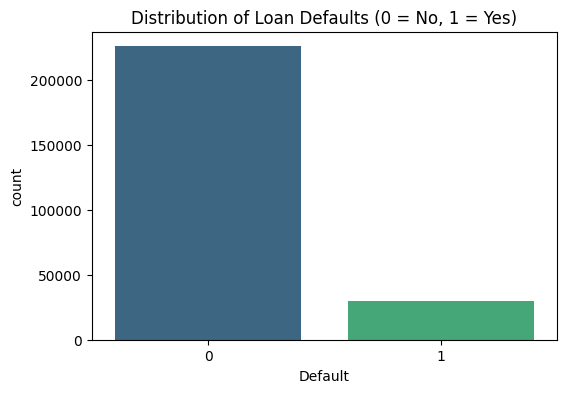

Default Rate: 11.61%


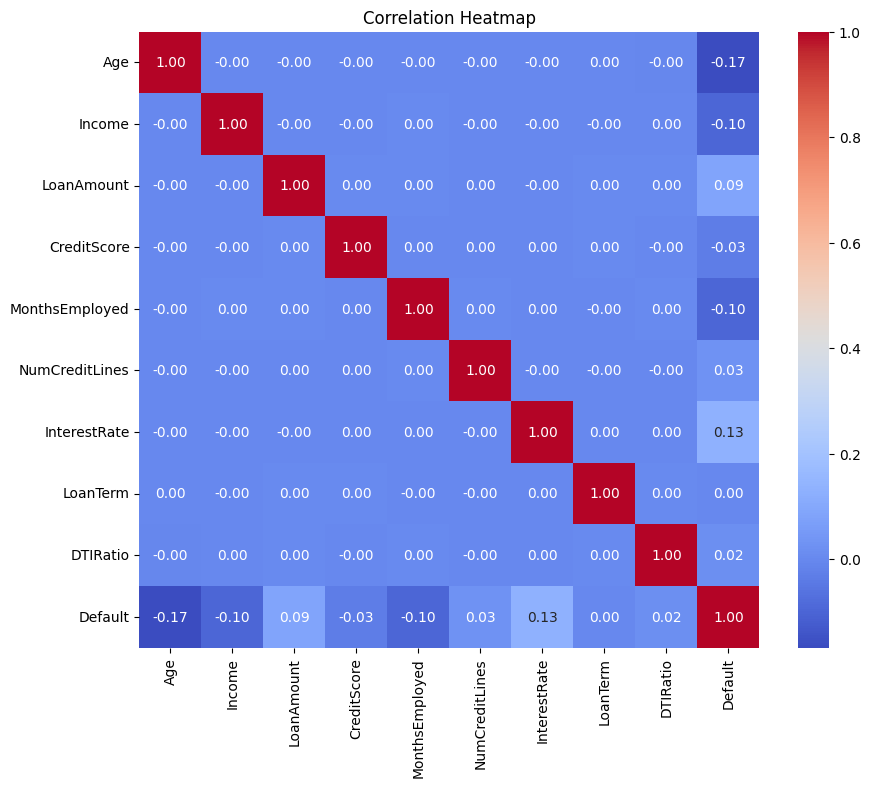

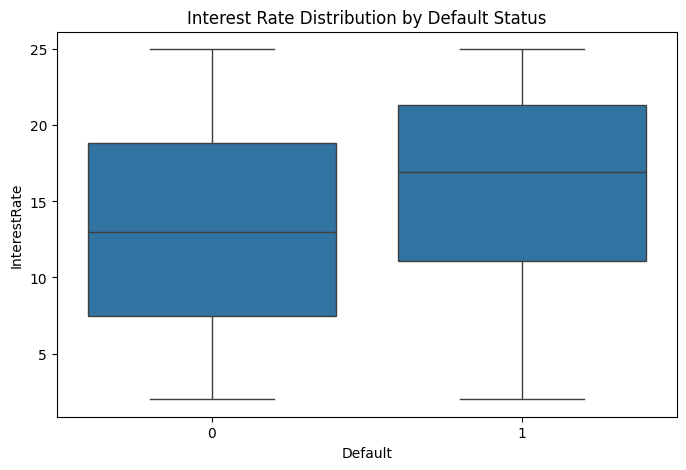

/tmp/ipykernel_18258/2103841019.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='EmploymentType', y='Default', data=df, ci=None)


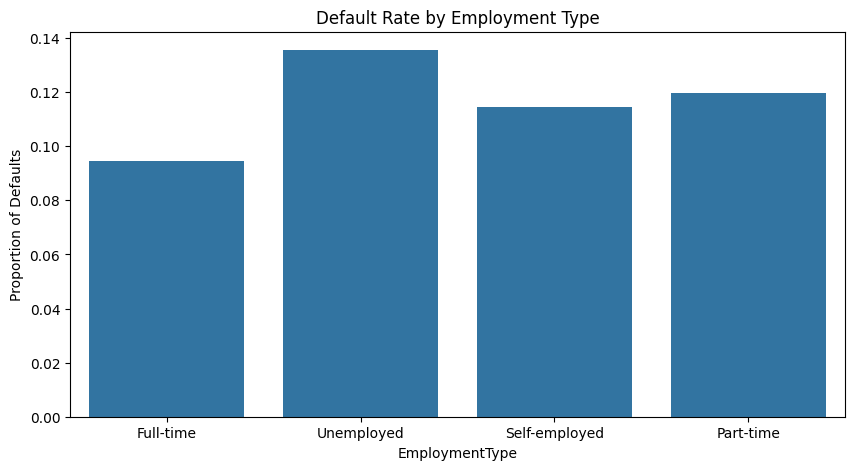


--- Statistical Test Results ---
T-Test (Interest Rate vs Default): p-value = 0.0000
Result: Interest Rate is a statistically significant factor in defaults.
Chi-Square Test (Employment Type vs Default): p-value = 0.0000
Result: Employment Type is statistically associated with loan defaults.


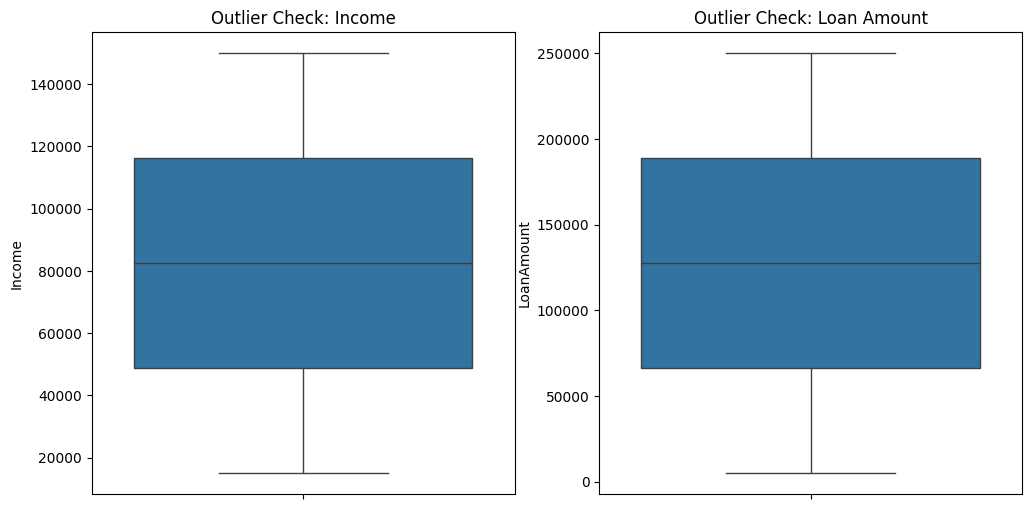

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# 1. Load the dataset
# If running on Colab, ensure you upload the file first or use:
# from google.colab import files
# uploaded = files.upload()
df = pd.read_csv('Loan_default.csv')

# --- TASK 3.1: Distribution of the Target Variable ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df, palette='viridis')
plt.title('Distribution of Loan Defaults (0 = No, 1 = Yes)')
plt.show()

print(f"Default Rate: {df['Default'].mean() * 100:.2f}%")

# --- TASK 3.2: Numerical Features and Correlation ---
# Calculate correlation matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Visualize a key numerical relationship: Interest Rate vs Default
plt.figure(figsize=(8, 5))
sns.boxplot(x='Default', y='InterestRate', data=df)
plt.title('Interest Rate Distribution by Default Status')
plt.show()

# --- TASK 3.3: Categorical Features Impact ---
# Default rate by Employment Type
plt.figure(figsize=(10, 5))
sns.barplot(x='EmploymentType', y='Default', data=df, ci=None)
plt.title('Default Rate by Employment Type')
plt.ylabel('Proportion of Defaults')
plt.show()

# --- TASK 3.4: Statistical Testing ---

# A. T-Test: Is there a significant difference in Interest Rate for defaulters?
group0 = df[df['Default'] == 0]['InterestRate']
group1 = df[df['Default'] == 1]['InterestRate']
t_stat, p_val_t = ttest_ind(group0, group1)

print("\n--- Statistical Test Results ---")
print(f"T-Test (Interest Rate vs Default): p-value = {p_val_t:.4f}")
if p_val_t < 0.05:
    print("Result: Interest Rate is a statistically significant factor in defaults.")

# B. Chi-Square Test: Does Employment Type impact Default status?
contingency_table = pd.crosstab(df['EmploymentType'], df['Default'])
chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test (Employment Type vs Default): p-value = {p_val_chi:.4f}")
if p_val_chi < 0.05:
    print("Result: Employment Type is statistically associated with loan defaults.")

# --- TASK 3.5: Identifying Outliers ---
# Using Boxplots for key numerical columns to identify extreme values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Income'])
plt.title('Outlier Check: Income')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['LoanAmount'])
plt.title('Outlier Check: Loan Amount')
plt.show()